# Reproduktion von Huang et al. (2010): Kapitel 6

**Pakete:** `numpy`, `pandas`, `matplotlib`, `scipy`, `cvxpy` (Solver `ECOS`).

**Ausführung:** Zellen von oben nach unten (*Run All*); den Datenpfad in der
ersten Codezelle über `CSV_PATH` setzen. 

Hinweis: Im Code steht `mu` für den in der Arbeit
als $\hat r^{\,i}$ bezeichneten geschätzten Renditevektor.

## 1. Daten laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pfad zur Kenneth-French-CSV, bei Bedarf an den eigenen Speicherort anpassen:
CSV_PATH = "30_Industry_Portfolios.csv"


# Daten laden
def load_30_industry_portfolios(csv_path, start="199701", end="200612"):
    """
    Liest den ersten Tabellenblock ("Average Value Weighted Returns -- Monthly")
    aus der Kenneth-French CSV und filtert auf [start, end].
    Rückgabe: DataFrame, Index = YYYYMM, Spalten = 30 Industry-Namen (Werte in Prozent).
    """
    with open(csv_path, "r") as f:
        lines = f.readlines()

    header_idx = next(i for i, l in enumerate(lines) if "Average Value Weighted Returns -- Monthly" in l)
    colnames_idx = header_idx + 1
    while lines[colnames_idx].strip() == "":
        colnames_idx += 1
    colnames = [c.strip() for c in lines[colnames_idx].strip().split(",")]
    colnames[0] = "date"

    data_rows = []
    i = colnames_idx + 1
    while i < len(lines) and lines[i].strip() != "":
        row = [v.strip() for v in lines[i].strip().split(",")]
        data_rows.append(row)
        i += 1

    df = pd.DataFrame(data_rows, columns=colnames)
    df["date"] = df["date"].astype(int)
    for c in colnames[1:]:
        df[c] = df[c].astype(float)
    df = df.set_index("date")
    df = df.loc[(df.index >= int(start)) & (df.index <= int(end))]
    df = df.replace([-99.99, -999], np.nan)
    return df


df = load_30_industry_portfolios(CSV_PATH)
print("Shape:", df.shape)
print("Zeitraum:", df.index.min(), "-", df.index.max())
df.head()

Shape: (120, 30)
Zeitraum: 199701 - 200612


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
date,,,,,,,,,,,,,,,,,,,,,
199701,3.20,11.37,4.59,3.80,0.88,6.73,5.21,9.57,3.78,5.60,...,2.29,5.76,10.36,1.07,2.20,-0.03,0.28,1.76,6.56,7.44
199702,2.72,2.74,12.45,-0.19,2.49,2.81,3.17,0.93,1.07,2.20,...,2.57,-4.99,-8.16,4.42,-1.13,-0.84,5.74,-2.84,3.93,-4.71
199703,-1.30,-6.53,-13.61,-3.21,0.70,-6.25,-4.95,-7.48,-2.17,-2.22,...,-7.83,-5.97,-5.22,-4.36,-0.13,-6.73,-0.74,1.20,-6.53,-4.27
199704,3.70,11.39,3.21,3.48,-0.90,8.73,-2.70,6.07,3.31,-5.05,...,2.49,9.18,6.02,3.63,5.72,0.38,1.64,5.90,6.02,0.69
199705,2.55,6.42,9.99,4.97,7.02,8.04,5.95,7.01,4.54,5.55,...,6.56,10.09,10.21,7.81,6.17,8.73,6.40,1.08,5.67,8.12


## 2. Aufteilung in Experten-Blöcke

In [2]:
def split_into_experts(returns, n_experts=4):
    """
    Teilt die Zeitreihe in n_experts disjunkte, gleich lange Blöcke auf
    (4 Experten, je 30 Beobachtungen).
    """
    n_obs = len(returns)
    assert n_obs % n_experts == 0, f"{n_obs} Beobachtungen nicht durch {n_experts} teilbar"
    block_size = n_obs // n_experts
    blocks = [returns.iloc[i*block_size:(i+1)*block_size] for i in range(n_experts)]
    return blocks


blocks = split_into_experts(df, 4)

for i, b in enumerate(blocks, start=1):
    print(f"Experte {i}: {b.index.min()} - {b.index.max()}  ({len(b)} Beobachtungen)")

Experte 1: 199701 - 199906  (30 Beobachtungen)
Experte 2: 199907 - 200112  (30 Beobachtungen)
Experte 3: 200201 - 200406  (30 Beobachtungen)
Experte 4: 200407 - 200612  (30 Beobachtungen)


## 3. Schätzung der Verteilungsparameter je Experte

Für jeden Experten $i$ werden Mittelwert $\hat\mu^i$ und Kovarianz $\hat\Sigma^i$
aus seinem 30-Monats-Block geschätzt, für das nominale Modell ($l=1$) zusätzlich
aus der vollen Stichprobe. Die Risiko-Konstante
$k_\epsilon=\varphi(\Phi^{-1}(\epsilon))/(1-\epsilon)$ hängt nur von
$\epsilon=0{,}95$ ab ($k_{0{,}95}\approx2{,}0627$). Die Experten-Kovarianzen sind
mit nur $T=30$ Beobachtungen rangdefizient (Rang 29/30), was die Rangausgabe
bestätigt. Herleitung und Einordnung: Abschnitt 6.1 der Arbeit.

In [3]:
from scipy.stats import norm

def k_epsilon(epsilon):
    """k_epsilon = phi(Phi^{-1}(epsilon)) / (1 - epsilon), Risiko-Konstante der Arbeit."""
    return norm.pdf(norm.ppf(epsilon)) / (1 - epsilon)


def estimate_moments(returns_block):
    """Schätzt Mittelwertvektor mu_hat und Kovarianzmatrix Sigma_hat aus einem Datenblock."""
    mu = returns_block.mean().to_numpy()
    Sigma = returns_block.cov().to_numpy()  # Stichprobenkovarianz (ddof=1)
    return mu, Sigma


epsilon = 0.95
k = k_epsilon(epsilon)
print(f"k_epsilon (epsilon={epsilon}) = {k:.4f}")

mu_list, Sigma_list = [], []
for i, b in enumerate(blocks, start=1):
    mu_i, Sigma_i = estimate_moments(b)
    mu_list.append(mu_i)
    Sigma_list.append(Sigma_i)
    rank = np.linalg.matrix_rank(Sigma_i)
    print(f"Experte {i}: mu-Range [{mu_i.min():.2f}, {mu_i.max():.2f}]  |  Rang(Sigma) = {rank}/30")

# Für das nominale CVaR-Modell (l=1) nutzen wir die volle Stichprobe (alle 120 Monate)
mu_full, Sigma_full = estimate_moments(df)
print(f"\nVolle Stichprobe: mu-Range [{mu_full.min():.2f}, {mu_full.max():.2f}]  |  Rang(Sigma) = {np.linalg.matrix_rank(Sigma_full)}/30")

k_epsilon (epsilon=0.95) = 2.0627
Experte 1: mu-Range [-0.34, 3.29]  |  Rang(Sigma) = 29/30
Experte 2: mu-Range [-1.64, 4.81]  |  Rang(Sigma) = 29/30
Experte 3: mu-Range [-0.59, 2.71]  |  Rang(Sigma) = 29/30
Experte 4: mu-Range [-0.20, 2.61]  |  Rang(Sigma) = 29/30

Volle Stichprobe: mu-Range [0.20, 2.91]  |  Rang(Sigma) = 30/30


### Matrixwurzel via Eigenwertzerlegung


In [4]:
def psd_sqrt(Sigma, tol=1e-10):
    """
    Robuste Matrixwurzel einer PSD- (möglicherweise singulären) Kovarianzmatrix
    über Eigenwertzerlegung. Liefert L mit L @ L.T = Sigma (symmetrische Wurzel),
    sodass ||L.T @ x||_2 = sqrt(x.T @ Sigma @ x) gilt.
    Numerisch negative Eigenwerte (Rundungsfehler) werden auf 0 abgeschnitten.
    """
    Sigma = (Sigma + Sigma.T) / 2  # numerische Symmetrisierung
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    eigvals_clipped = np.clip(eigvals, 0, None)
    if np.any(eigvals < -tol):
        print(f"  [Warnung] kleinster Eigenwert {eigvals.min():.2e} < 0, wurde auf 0 gesetzt.")
    L = eigvecs @ np.diag(np.sqrt(eigvals_clipped))
    return L


# Test: Rekonstruktion pruefen fuer alle 4 Experten + volle Stichprobe
for i, Sigma_i in enumerate(Sigma_list, start=1):
    L_i = psd_sqrt(Sigma_i)
    recon_error = np.abs(L_i @ L_i.T - Sigma_i).max()
    print(f"Experte {i}: max. Rekonstruktionsfehler L@L.T vs. Sigma = {recon_error:.2e}")

L_full = psd_sqrt(Sigma_full)
recon_error_full = np.abs(L_full @ L_full.T - Sigma_full).max()
print(f"Volle Stichprobe: max. Rekonstruktionsfehler = {recon_error_full:.2e}")

Experte 1: max. Rekonstruktionsfehler L@L.T vs. Sigma = 2.20e-13
Experte 2: max. Rekonstruktionsfehler L@L.T vs. Sigma = 2.42e-13
Experte 3: max. Rekonstruktionsfehler L@L.T vs. Sigma = 2.34e-13
Experte 4: max. Rekonstruktionsfehler L@L.T vs. Sigma = 1.14e-13
Volle Stichprobe: max. Rekonstruktionsfehler = 1.99e-13


## 4. Optimierungsmodelle

Alle drei Strategien werden als Second-Order Cone Programs (SOCP) mit `cvxpy` und dem
Innere-Punkte-Solver `ECOS` gelöst. Parametrisierung durchgehend: Budget
$e^\top x = w_0 = 1$, Positionsschranken $0 \le x \le 1$ (keine Leerverkäufe, kein
Leverage), Konfidenzniveau $\epsilon = 0{,}95$.

### 4.1 Nominales CVaR

In [5]:
import cvxpy as cp

def solve_nominal_cvar(mu, Sigma, target_mu, w0=1.0, x_lower=0.0, x_upper=1.0, k=None):
    """
    Nominales CVaR-Portfolio (l=1, eine einzige geschätzte Verteilung, volle Stichprobe).
    min_x  -x^T mu + k * ||L^T x||_2
    s.t.   x^T mu >= target_mu, Budget e^T x = w0, x_lower <= x <= x_upper
    """
    n = len(mu)
    L = psd_sqrt(Sigma)
    x = cp.Variable(n)

    objective = cp.Minimize(-x @ mu + k * cp.norm(L.T @ x, 2))
    constraints = [
        cp.sum(x) == w0,
        x >= x_lower,
        x <= x_upper,
        x @ mu >= target_mu,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status


# Test für target_mu = 1.15 (erste Zeile aus Tabelle 1)
target_mu = 1.15
x_cvar, val, status = solve_nominal_cvar(mu_full, Sigma_full, target_mu, k=k)

print("Solver-Status:", status)
print("Optimaler CVaR-Wert (auf voller Stichprobe):", round(val, 4))
print("Summe der Gewichte:", round(x_cvar.sum(), 4))
print("Min/Max Gewicht:", round(x_cvar.min(), 4), "/", round(x_cvar.max(), 4))
print("Anzahl Assets mit Gewicht > 1%:", (x_cvar > 0.01).sum())

Solver-Status: optimal
Optimaler CVaR-Wert (auf voller Stichprobe): 5.9414
Summe der Gewichte: 1.0
Min/Max Gewicht: -0.0 / 0.2294
Anzahl Assets mit Gewicht > 1%: 8


In [17]:
def evaluate_portfolio(x, mu_list, Sigma_list, k):
    """
    Wertet ein gegebenes Portfolio x gegen jede der l Expertenverteilungen aus:
    liefert (mean_i, cvar_i) für i = 1..l -- das sind die Spalten aus Tabelle 1.
    """
    means, cvars = [], []
    for mu_i, Sigma_i in zip(mu_list, Sigma_list):
        L_i = psd_sqrt(Sigma_i)
        mean_i = x @ mu_i
        cvar_i = -x @ mu_i + k * np.linalg.norm(L_i.T @ x, 2)
        means.append(mean_i)
        cvars.append(cvar_i)
    return means, cvars


means, cvars = evaluate_portfolio(x_cvar, mu_list, Sigma_list, k)

print(" Nominal-CVaR-Portfolio, ausgewertet je Experte")
print("Mean je Experte:  ", [round(m, 4) for m in means])
print("CVaR je Experte:  ", [round(c, 4) for c in cvars])
print()


 Nominal-CVaR-Portfolio, ausgewertet je Experte
Mean je Experte:   [np.float64(1.9314), np.float64(1.445), np.float64(1.1027), np.float64(1.7209)]
CVaR je Experte:   [np.float64(7.8304), np.float64(8.5237), np.float64(10.4343), np.float64(5.5749)]



### Kontrollrechnung: unrestringiertes Minimum-CVaR-Portfolio

Zur Einordnung der Renditeniveaus wird das nominale CVaR-Portfolio ohne
Mindestrendite-Restriktion (nur Budget und Positionsschranken) gelöst. Der über die
vier Experten gemittelte Mean dient in Abschnitt 6.3.1 der Arbeit als Beleg für die
Abweichung des Renditeniveaus gegenüber der Originalarbeit.

In [7]:
# Test: Wie hoch ist die Rendite des *unrestringierten* Minimum-CVaR-Portfolios
# (nur Budget/Bounds, keine Mindestrendite)?
x_free, val_free, status_free = solve_nominal_cvar(mu_full, Sigma_full, target_mu=-100, k=k)

print("Status:", status_free)
print("Natürliche Rendite (volle Stichprobe):", round(x_free @ mu_full, 4))

means_free, cvars_free = evaluate_portfolio(x_free, mu_list, Sigma_list, k)
print("Mean je Experte (unrestringiert):", [round(m, 4) for m in means_free])
print("Durchschnitt der 4 Experten-Means:", round(np.mean(means_free), 4))

Status: optimal
Natuerliche Rendite (volle Stichprobe): 0.9271
Mean je Experte (unrestringiert): [np.float64(1.757), np.float64(0.4503), np.float64(0.5071), np.float64(0.9939)]
Durchschnitt der 4 Experten-Means: 0.9271


### 4.2 WCVaR (Worst-Case über alle Experten)

In [8]:
def solve_wcvar(mu_list, Sigma_list, target_mu, w0=1.0, x_lower=0.0, x_upper=1.0, k=None):
    """
    Worst-Case-CVaR-Portfolio über l Experten,
    min_{x,theta} theta
    s.t. -x^T mu_i + k ||L_i^T x||_2 <= theta,  i=1..l   (Risiko-Restriktion je Experte)
         x^T mu_i >= target_mu,                  i=1..l   (Rendite-Restriktion je Experte)
         Budget, Bounds
    """
    n = len(mu_list[0])
    L_list = [psd_sqrt(S) for S in Sigma_list]

    x = cp.Variable(n)
    theta = cp.Variable()

    constraints = [cp.sum(x) == w0, x >= x_lower, x <= x_upper]
    for mu_i, L_i in zip(mu_list, L_list):
        constraints += [-x @ mu_i + k * cp.norm(L_i.T @ x, 2) <= theta]
        constraints += [x @ mu_i >= target_mu]

    prob = cp.Problem(cp.Minimize(theta), constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status


x_wc, val_wc, status_wc = solve_wcvar(mu_list, Sigma_list, target_mu, k=k)

print("Status:", status_wc)
means_wc, cvars_wc = evaluate_portfolio(x_wc, mu_list, Sigma_list, k)
print("Mean je Experte:  ", [round(m, 4) for m in means_wc])
print("CVaR je Experte:  ", [round(c, 4) for c in cvars_wc])
print("Minimale Mean über alle Experten (garantierte Worst-Case-Rendite):", round(min(means_wc), 4))

Status: optimal
Mean je Experte:   [np.float64(1.4133), np.float64(1.15), np.float64(1.15), np.float64(1.2076)]
CVaR je Experte:   [np.float64(7.6619), np.float64(7.6619), np.float64(7.6619), np.float64(4.6872)]
Minimale Mean ueber alle Experten (garantierte Worst-Case-Rendite): 1.15


### 4.3 RCVaR (Relative Robust CVaR)

Zweistufiges Vorgehen: Zunächst wird für jeden Experten der Benchmark
$\psi^*(\hat\mu^i,\hat\Sigma^i)$ des perfekt informierten Investors berechnet, anschließend das Regret-minimierende Hauptproblem gelöst.

In [9]:
def solve_benchmark(mu_i, Sigma_i, target_mu, w0=1.0, x_lower=0.0, x_upper=1.0, k=None):
    """
    Berechnet psi*(mu_i, Sigma_i) = min_{z in X_i} { -z^T mu_i + k ||L_i^T z|| },
     X_i verwendet nur die Renditebeschraenkung von Experte i
    (nicht allen Experten!), das ist der "perfekt informierte Investor".
    """
    n = len(mu_i)
    L_i = psd_sqrt(Sigma_i)
    z = cp.Variable(n)

    objective = cp.Minimize(-z @ mu_i + k * cp.norm(L_i.T @ z, 2))
    constraints = [
        cp.sum(z) == w0,
        z >= x_lower,
        z <= x_upper,
        z @ mu_i >= target_mu,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)
    return prob.value


def solve_rcvar(mu_list, Sigma_list, target_mu, w0=1.0, x_lower=0.0, x_upper=1.0, k=None):
    """
    Relative-Robust-CVaR-Portfolio,
    Schritt 1: psi*_i für jeden Experten vorab berechnen.
    Schritt 2: Hauptproblem mit Regret-Restriktion lösen.
    """
    n = len(mu_list[0])
    L_list = [psd_sqrt(S) for S in Sigma_list]

    psi_star = [
        solve_benchmark(mu_i, S_i, target_mu, w0, x_lower, x_upper, k)
        for mu_i, S_i in zip(mu_list, Sigma_list)
    ]

    x = cp.Variable(n)
    theta = cp.Variable()

    constraints = [cp.sum(x) == w0, x >= x_lower, x <= x_upper]
    for mu_i, L_i, psi_i in zip(mu_list, L_list, psi_star):
        constraints += [-x @ mu_i + k * cp.norm(L_i.T @ x, 2) - psi_i <= theta]
        constraints += [x @ mu_i >= target_mu]

    prob = cp.Problem(cp.Minimize(theta), constraints)
    prob.solve(solver=cp.ECOS)
    return x.value, prob.value, prob.status, psi_star


x_rc, val_rc, status_rc, psi_star = solve_rcvar(mu_list, Sigma_list, target_mu, k=k)

print("Status:", status_rc)
print("psi* je Experte (Benchmark-CVaR, perfekt informierter Investor):", [round(p, 4) for p in psi_star])
print()
means_rc, cvars_rc = evaluate_portfolio(x_rc, mu_list, Sigma_list, k)
print("Mean je Experte:  ", [round(m, 4) for m in means_rc])
print("CVaR je Experte:  ", [round(c, 4) for c in cvars_rc])

Status: optimal
psi* je Experte (Benchmark-CVaR, perfekt informierter Investor): [np.float64(4.9653), np.float64(6.6805), np.float64(4.0836), np.float64(1.4257)]

Mean je Experte:   [np.float64(1.4313), np.float64(1.15), np.float64(1.15), np.float64(1.15)]
CVaR je Experte:   [np.float64(8.1111), np.float64(8.4607), np.float64(7.2294), np.float64(4.5714)]


## 5. CVaR-Zerlegung in Rendite- und Risikokomponente

Zerlegung $\text{CVaR}_i(x) = \underbrace{-x^\top\mu_i}_{(a)} + \underbrace{k_\epsilon\sqrt{x^\top\Sigma_i x}}_{(b)}$
zur Interpretation der Ergebnisse (Abschnitt 6.4 der Arbeit). Es werden pro Experte
vier und acht Nachkommastellen ausgegeben: Die achtstellige Darstellung belegt, dass
das WCVaR-Portfolio bei $\mu=1{,}15$ für die Experten 1, 2 und 3 auf exakt denselben
CVaR-Wert führt (drei gleichzeitig aktive Restriktionen).

In [10]:
def decompose_cvar(x, mu_list, Sigma_list, k):
    """
    Zerlegt CVaR_i(x) = (a) Renditekomponente + (b) Risikoaufschlag
    für jeden Experten, um die Struktur der Formel sichtbarer zu machen.
    Ausgabe je Experte mit 4 und 8 Nachkommastellen (8 Stellen belegen die exakte
    Gleichheit mehrerer aktiver Restriktionen).
    """
    print(f"{'Experte':<10}{'(a) -x^T mu':>15}{'(b) k*sigma_P':>15}{'CVaR = a+b':>15}")
    for i, (mu_i, Sigma_i) in enumerate(zip(mu_list, Sigma_list), start=1):
        L_i = psd_sqrt(Sigma_i)
        a = -x @ mu_i                              # Renditekomponente
        b = k * np.linalg.norm(L_i.T @ x, 2)        # Risikoaufschlag (k * sigma_P)
        print(f"{i:<10}{a:>15.4f}{b:>15.4f}{a+b:>15.4f}")
        print(f"{i:<10}{a:>15.8f}{b:>15.8f}{a+b:>15.8f}")

print("Zerlegung für das WCVaR-Portfolio ")
decompose_cvar(x_wc, mu_list, Sigma_list, k)

=== Zerlegung fuer das WCVaR-Portfolio ===
Experte       (a) -x^T mu  (b) k*sigma_P     CVaR = a+b
1                 -1.4133         9.0753         7.6619
1             -1.41333282     9.07526344     7.66193062
2                 -1.1500         8.8119         7.6619
2             -1.15000000     8.81193062     7.66193062
3                 -1.1500         8.8119         7.6619
3             -1.15000000     8.81193062     7.66193062
4                 -1.2076         5.8948         4.6872
4             -1.20761139     5.89481244     4.68720105


## 7. Reproduktion von Tabelle 1

Für jeden der neun Zielwerte $\mu \in \{1{,}15,\dots,1{,}55\}$ werden alle drei
Strategien gelöst und gegen jeden der vier Experten ausgewertet (Mean und CVaR).

In [13]:
mu_values = [1.15, 1.20, 1.25, 1.30, 1.35, 1.40, 1.45, 1.50, 1.55]

results = []

for target_mu in mu_values:
    row = {"mu": target_mu}

    # Nominal CVaR 
    x_cvar, _, status_cvar = solve_nominal_cvar(mu_full, Sigma_full, target_mu, k=k)
    if status_cvar == "optimal":
        means, cvars = evaluate_portfolio(x_cvar, mu_list, Sigma_list, k)
        row["CVaR_mean"] = means
        row["CVaR_cvar"] = cvars
    else:
        row["CVaR_mean"] = row["CVaR_cvar"] = [np.nan]*4

    #  WCVaR 
    x_wc, _, status_wc = solve_wcvar(mu_list, Sigma_list, target_mu, k=k)
    if status_wc == "optimal":
        means, cvars = evaluate_portfolio(x_wc, mu_list, Sigma_list, k)
        row["WCVaR_mean"] = means
        row["WCVaR_cvar"] = cvars
    else:
        row["WCVaR_mean"] = row["WCVaR_cvar"] = [np.nan]*4

    #  RCVaR
    x_rc, _, status_rc, psi_star_i = solve_rcvar(mu_list, Sigma_list, target_mu, k=k)
    if status_rc == "optimal":
        means, cvars = evaluate_portfolio(x_rc, mu_list, Sigma_list, k)
        row["RCVaR_mean"] = means
        row["RCVaR_cvar"] = cvars
        row["psi_star"] = psi_star_i
    else:
        row["RCVaR_mean"] = row["RCVaR_cvar"] = row["psi_star"] = [np.nan]*4

    row["status"] = (status_cvar, status_wc, status_rc)
    results.append(row)

    print(f"mu={target_mu}: CVaR={status_cvar}, WCVaR={status_wc}, RCVaR={status_rc}")

mu=1.15: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.2: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.25: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.3: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.35: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.4: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.45: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.5: CVaR=optimal, WCVaR=optimal, RCVaR=optimal
mu=1.55: CVaR=optimal, WCVaR=optimal, RCVaR=optimal


In [14]:
# Zeilen: mu-Wert x Strategie (CVaR/WCVaR/RCVaR)
# Spalten: Mean (Experte 1-4), CVaR (Experte 1-4)

rows = []
for r in results:
    for strategy in ["CVaR", "WCVaR", "RCVaR"]:
        rows.append({
            "mu": r["mu"],
            "Strategie": strategy,
            "Mean_E1": r[f"{strategy}_mean"][0],
            "Mean_E2": r[f"{strategy}_mean"][1],
            "Mean_E3": r[f"{strategy}_mean"][2],
            "Mean_E4": r[f"{strategy}_mean"][3],
            "CVaR_E1": r[f"{strategy}_cvar"][0],
            "CVaR_E2": r[f"{strategy}_cvar"][1],
            "CVaR_E3": r[f"{strategy}_cvar"][2],
            "CVaR_E4": r[f"{strategy}_cvar"][3],
        })

table1_df = pd.DataFrame(rows)
table1_df = table1_df.set_index(["mu", "Strategie"])
table1_df = table1_df.round(4)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
table1_df

Mean_E1  Mean_E2  Mean_E3  Mean_E4  CVaR_E1  CVaR_E2  CVaR_E3  CVaR_E4
mu   Strategie                                                                        
1.15 CVaR        1.8860   0.7440   0.6578   1.3122   6.0397   6.3540   7.6222   3.1941
     WCVaR       1.4133   1.1500   1.1500   1.2076   7.6619   7.6619   7.6619   4.6872
     RCVaR       1.4313   1.1500   1.1500   1.1500   8.1111   8.4607   7.2294   4.5714
1.20 CVaR        1.9111   0.8193   0.7013   1.3682   6.1634   6.4713   7.9384   3.4170
     WCVaR       1.3788   1.2000   1.2000   1.2506   7.8421   7.8421   7.8421   4.8559
     RCVaR       1.3683   1.2000   1.2000   1.2000   8.2143   8.6248   7.5037   4.6746
1.25 CVaR        1.9198   0.9051   0.7551   1.4200   6.3349   6.6392   8.2570   3.6686
     WCVaR       1.3475   1.2500   1.2500   1.2930   8.0325   8.0325   8.0325   5.0348
     RCVaR       1.2854   1.2500   1.2500   1.2500   8.3035   8.8159   7.8187   4.7638
1.30 CVaR        1.9217   0.9951   0.8130   1.4702   6.5382   6.8570   8.5872   3.9463
     WCVaR       1.3231   1.3000   1.3000   1.3190   8.2357   8.2357   8.2357   5.2541
     RCVaR       1.3000   1.3000   1.3000   1.3175   8.4380   8.6846   8.2263   4.8984
1.35 CVaR        1.9237   1.0851   0.8710   1.5203   6.7620   7.1203   8.9326   4.2439
     WCVaR       1.3500   1.3500   1.3500   1.3561   8.4650   8.4650   8.4650   5.5026
     RCVaR       1.3500   1.3500   1.3500   1.3962   8.6201   8.5838   8.7215   5.0922
1.40 CVaR        1.9256   1.1750   0.9289   1.5705   7.0046   7.4236   9.2915   4.5582
     WCVaR       1.4000   1.4000   1.4000   1.4000   8.7331   8.7400   8.7400   5.7704
     RCVaR       1.4000   1.4000   1.4000   1.4853   8.8254   8.7212   9.2735   5.3295
1.45 CVaR        1.9275   1.2650   0.9868   1.6206   7.2644   7.7617   9.6624   4.8862
     WCVaR       1.4500   1.4500   1.4500   1.4528   9.0689   9.0689   9.0689   6.0758
     RCVaR       1.4500   1.4500   1.4500   1.5730   9.0467   9.0359   9.8695   5.6077
1.50 CVaR        1.9295   1.3550   1.0448   1.6707   7.5402   8.1298  10.0437   5.2257
     WCVaR       1.5000   1.5000   1.5000   1.5195   9.4586   9.4586   9.4586   6.4311
     RCVaR       1.5000   1.5000   1.5000   1.6635   9.2835   9.4985  10.5046   5.9193
1.55 CVaR        1.9314   1.4450   1.1027   1.7209   7.8304   8.5237  10.4343   5.5749
     WCVaR       1.5500   1.5500   1.5500   1.6019   9.8332   9.9085   9.9085   6.8563
     RCVaR       1.5500   1.5500   1.5500   1.7912   9.5921  10.2980  11.2309   6.3148

## 8. Reproduktion von Figure 1

Maximales Regret der WCVaR- und RCVaR-optimalen Portfolios in Abhängigkeit der
geforderten Mindestrendite $\mu$. Die erzeugte Grafik wird als
`figure1_reproduktion.png` gespeichert und in der Arbeit als Abbildung eingebunden.

In [15]:
regret_rows = []
for r in results:
    psi = r["psi_star"]
    regret_wc_i = [c - p for c, p in zip(r["WCVaR_cvar"], psi)]
    regret_rc_i = [c - p for c, p in zip(r["RCVaR_cvar"], psi)]
    regret_rows.append({
        "mu": r["mu"],
        "max_regret_WCVaR": max(regret_wc_i),
        "max_regret_RCVaR": max(regret_rc_i),
        "RCVaR_besser": max(regret_rc_i) < max(regret_wc_i),
    })

regret_df = pd.DataFrame(regret_rows).set_index("mu").round(4)
regret_df

,max_regret_WCVaR,max_regret_RCVaR,RCVaR_besser
mu,,,
1.15,3.5783,3.1457,True
1.20,3.5874,3.2490,True
1.25,3.6091,3.3381,True
1.30,3.8284,3.4727,True
1.35,4.0651,3.6548,True
1.40,4.3009,3.8601,True
1.45,4.5495,4.0813,True
1.50,4.8300,4.3182,True
1.55,5.1683,4.6268,True


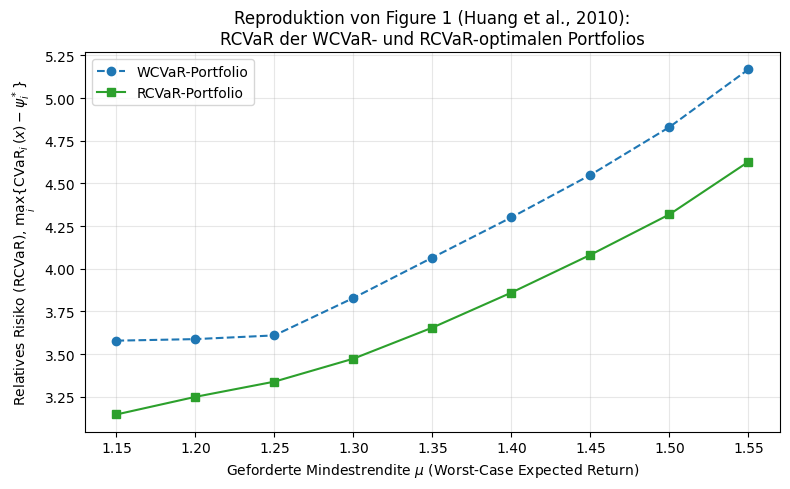

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(regret_df.index, regret_df["max_regret_WCVaR"],
        marker='o', linestyle='--', label='WCVaR-Portfolio', color='tab:blue')
ax.plot(regret_df.index, regret_df["max_regret_RCVaR"],
        marker='s', linestyle='-', label='RCVaR-Portfolio', color='tab:green')

ax.set_xlabel(r'Geforderte Mindestrendite $\mu$ (Worst-Case Expected Return)')
ax.set_ylabel(r'Relatives Risiko (RCVaR), $\max_i\{\mathrm{CVaR}_i(x) - \psi_i^*\}$')
ax.set_title('Reproduktion von Figure 1 (Huang et al., 2010):\nRCVaR der WCVaR- und RCVaR-optimalen Portfolios')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figure1_reproduktion.png", dpi=150)
plt.show()